In [1]:
# -------------------------------------------------------------
# Fine-tune a Hugging Face ResNet-50 (pretrained on ImageNet)
# for binary classification
# -------------------------------------------------------------

In [1]:
import torch
print(torch.__version__)

2.6.0+cu118


In [2]:
#you can create the model with specific configutation. e.g with BertConfig file we can create BertModel with same
#architecture in single line of code.
from transformers import BertConfig, BertModel
bert_config= BertConfig.from_pretrained('bert-base-cased')
bert_model=BertModel(bert_config)


In [3]:
bert_model.

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [43]:
from transformers import AutoModelForSequenceClassification

model=AutoModelForSequenceClassification.from_pretrained(checkpoint)
model(ids1)

SequenceClassifierOutput(loss=None, logits=tensor([[ 2.9626, -2.4565]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

## Trainer API

In [2]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset

raw_datasets=load_dataset("glue","mrpc")

checkpoint="bert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(example):
    return tokenizer(
        example['sentence1'], example['sentence2'],truncation=True
    )
tokenized_datasets=raw_datasets.map(tokenize_function,batched=True)

data_collator=DataCollatorWithPadding(tokenizer)


In [3]:
tokenized_datasets


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

In [4]:
from transformers import AutoModelForSequenceClassification as am
model=am.from_pretrained(checkpoint,num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
from transformers import TrainingArguments

training_args=TrainingArguments("test-trainer")
print(training_args)

TrainingArguments(
_n_gpu=2,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=False,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=no,
eval_use_gather_object=F

In [6]:
from transformers import Trainer
trainer=Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
)
trainer.train()

/tmp/ipykernel_40369/754112142.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(
Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
500,0.358700


/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=690, training_loss=0.28621589550073595, metrics={'train_runtime': 162.4226, 'train_samples_per_second': 67.749, 'train_steps_per_second': 4.248, 'total_flos': 445220905661280.0, 'train_loss': 0.28621589550073595, 'epoch': 3.0})

## Image Training 

In [6]:
from transformers import AutoFeatureExtractor
from PIL import Image
import requests
import torch

image = Image.open("/home/prudhvi/NNPractice/Datasetv2/R_3_DS/0/n01698640_38.JPEG")

extractor = AutoFeatureExtractor.from_pretrained(checkpoint)
inputs = extractor(images=image, return_tensors="pt")

outputs = model(**inputs)
logits = outputs.logits
predicted_class = logits.argmax(-1)
print(predicted_class)


OSError: bert-base-cased does not appear to have a file named preprocessor_config.json. Checkout 'https://huggingface.co/bert-base-cased/tree/main'for available files.

In [9]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch

# 1. Model identifier
model_id = "soufyane/dogs-vs-cats"

# 2. Load processor + model
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id)

# 3. Load image
img = Image.open("your_image.jpg").convert("RGB")

# 4. Preprocess
inputs = processor(images=img, return_tensors="pt")

# 5. Inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# 6. Get predicted class
pred_idx = logits.argmax(-1).item()
label = model.config.id2label.get(pred_idx, str(pred_idx))

print("Predicted class:", label)


OSError: soufyane/dogs-vs-cats does not appear to have a file named preprocessor_config.json. Checkout 'https://huggingface.co/soufyane/dogs-vs-cats/tree/main'for available files.

In [65]:
!pip install accelerate>=0.26.0

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [45]:
#Image related models
from transformers import pipeline

classifier = pipeline("image-classification", model="google/vit-base-patch16-224")




Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


[{'label': 'jellyfish', 'score': 0.9993283748626709}, {'label': 'digital clock', 'score': 8.091425843304023e-05}, {'label': 'sea anemone, anemone', 'score': 1.8591263142297976e-05}, {'label': 'running shoe', 'score': 1.7880336599773727e-05}, {'label': 'analog clock', 'score': 1.3207552910898812e-05}]


In [46]:
result = classifier("/home/prudhvi/NNPractice/Datasetv2/R_7_DS/1/n01910747_83.JPEG")
print(result)

[{'label': 'jellyfish', 'score': 0.9996436834335327}, {'label': 'sea anemone, anemone', 'score': 3.657976048998535e-05}, {'label': 'running shoe', 'score': 1.3297385521582328e-05}, {'label': 'electric ray, crampfish, numbfish, torpedo', 'score': 8.372915544896387e-06}, {'label': 'isopod', 'score': 7.578197255497798e-06}]


In [47]:
#some other image models
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch

image = Image.open("/home/prudhvi/NNPractice/Datasetv2/R_3_DS/0/n01698640_38.JPEG")

##there is processor to process the input, i don't need to do much.
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-18")
model = AutoModelForImageClassification.from_pretrained("microsoft/resnet-18")

inputs = processor(image, return_tensors="pt")
outputs = model(**inputs).logits
pred = outputs.argmax(-1).item()

print("Predicted class:", model.config.id2label[pred])


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Predicted class: American alligator, Alligator mississipiensis


## Vit Base path16-224 Model

In [11]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

image = Image.open("/home/prudhvi/NNPractice/Datasetv2/R_3_DS/0/n01698640_38.JPEG")

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])


Predicted class: American alligator, Alligator mississipiensis


In [14]:
model

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBottleNeckLayer(
              (shortcut): ResNetShortCut(
                (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64

In [12]:
from transformers import AutoFeatureExtractor, ResNetForImageClassification
import torch
from datasets import load_dataset

#dataset = load_dataset("huggingface/cats-image")
#image = dataset["test"]["image"][0]

image = Image.open("/home/prudhvi/NNPractice/Datasetv2/R_3_DS/0/n01698640_38.JPEG")

feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/resnet-101")
model = ResNetForImageClassification.from_pretrained("microsoft/resnet-101")

inputs = feature_extractor(image, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits

# model predicts one of the 1000 ImageNet classes
predicted_label = logits.argmax(-1).item()
print(model.config.id2label[predicted_label])


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/transformers/models/convnext/feature_extraction_convnext.py:28: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

American alligator, Alligator mississipiensis


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

In [15]:
from transformers import AutoImageProcessor, ResNetForImageClassification
import torch
from datasets import load_dataset

image = Image.open("/home/prudhvi/NNPractice/Datasetv2/R_3_DS/0/n01698640_38.JPEG")

processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")

inputs = processor(image, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits

# model predicts one of the 1000 ImageNet classes
predicted_label = logits.argmax(-1).item()
print(model.config.id2label[predicted_label])


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

American alligator, Alligator mississipiensis


In [16]:
model

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBottleNeckLayer(
              (shortcut): ResNetShortCut(
                (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64

In [17]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("microsoft/resnet-18")
print(config.


ResNetConfig {
  "architectures": [
    "ResNetForImageClassification"
  ],
  "depths": [
    2,
    2,
    2,
    2
  ],
  "downsample_in_bottleneck": false,
  "downsample_in_first_stage": false,
  "embedding_size": 64,
  "hidden_act": "relu",
  "hidden_sizes": [
    64,
    128,
    256,
    512
  ],
  "id2label": {
    "0": "tench, Tinca tinca",
    "1": "goldfish, Carassius auratus",
    "2": "great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias",
    "3": "tiger shark, Galeocerdo cuvieri",
    "4": "hammerhead, hammerhead shark",
    "5": "electric ray, crampfish, numbfish, torpedo",
    "6": "stingray",
    "7": "cock",
    "8": "hen",
    "9": "ostrich, Struthio camelus",
    "10": "brambling, Fringilla montifringilla",
    "11": "goldfinch, Carduelis carduelis",
    "12": "house finch, linnet, Carpodacus mexicanus",
    "13": "junco, snowbird",
    "14": "indigo bunting, indigo finch, indigo bird, Passerina cyanea",
    "15": "robin, American robi

## Resnet 18

In [ ]:
from datasets import load_dataset
from transformers import TrainingArguments, Trainer

dataset = load_dataset("imagefolder", data_dir="/home/prudhvi/NNPractice/Datasetv2")

### Importing Dataset

In [49]:
from datasets import load_dataset

dataset = load_dataset(
    "imagefolder",
    data_dir="/home/prudhvi/NNPractice/Datasetv2/NR_1_DS",
    split={"train": "train[:80%]", "validation": "train[80%:]"}
)

print(dataset)

Resolving data files:   0%|          | 0/2325 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1860
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 465
    })
})


In [93]:
print(dataset["train"][0].keys())


AttributeError: 'list' object has no attribute 'read'

In [53]:
print(dataset["train"].column_names)

['image', 'label']


In [21]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from datasets import load_dataset
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score

# ----------------------------
# Step 1: Define image transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----------------------------
# Step 2: Load local dataset using `datasets` library
# ----------------------------
# Folder structure:
# dataset/
#   train/class0, train/class1
#   val/class0, val/class1

dataset = load_dataset(
    "imagefolder",
    data_dir="/home/prudhvi/NNPractice/Datasetv2/NR_1_DS",
    split={"train": "train[:80%]", "validation": "train[80%:]"}
)

#print(dataset)

# Apply transforms
def transform_examples(example):
    from PIL import Image
    example["pixel_values"] = train_transform(Image.open(example["image"])) if example["split"]=="train" else val_transform(Image.open(example["image"]))
    return example

dataset = dataset.with_transform(transform_examples)

# ----------------------------
# Step 3: Load pre-trained ResNet-18
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
model = model.to(device)

# ----------------------------
# Step 4: Define compute_metrics
# ----------------------------
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# ----------------------------
# Step 5: Define a custom DataCollator
# ----------------------------
from torch.utils.data import DataLoader

def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    labels = torch.tensor([x["label"] for x in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# ----------------------------
# Step 6: TrainingArguments
# ----------------------------
training_args = TrainingArguments(
    output_dir="./resnet18_binary",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=1e-4,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

# ----------------------------
# Step 7: Trainer
# ----------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=None,  # not needed for images
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

# ----------------------------
# Step 8: Train the model
# ----------------------------
trainer.train()

# ----------------------------
# Step 9: Evaluate
# ----------------------------
results = trainer.evaluate()
print("Validation results:", results)

# ----------------------------
# Step 10: Save model
# ----------------------------
trainer.save_model("/home/prudhvi/NNPractice/Datasetv2/NR_1_resnet18_binary")


Resolving data files:   0%|          | 0/2325 [00:00<?, ?it/s]

/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/prudhvi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:08<00:00, 5.73MB/s]
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/transform

KeyError: 'split'

In [54]:
def transform_train(example):
    example["pixel_values"] = train_transform(Image.open(example["image"]).convert("RGB"))
    return example

def transform_val(example):
    example["pixel_values"] = val_transform(Image.open(example["image"]).convert("RGB"))
    print(example)
    return example



Dataset({
    features: ['image', 'label'],
    num_rows: 1860
})
<class 'datasets.arrow_dataset.Dataset'>


In [55]:
dataset["train"][0]

AttributeError: 'list' object has no attribute 'read'

## Pretrained Vit fineturning with NR_9_DS

In [20]:
from datasets import load_dataset

NR_9_DS = load_dataset(
    "imagefolder",
    data_dir="/home/prudhvi/NNPractice/Datasetv2/NR_9_DS/",
    split={"train": "train[:80%]", "validation": "train[80%:]"}
)

print(NR_9_DS)

Resolving data files:   0%|          | 0/3711 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2969
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 742
    })
})


In [21]:
NR_9_DS["train"]

Dataset({
    features: ['image', 'label'],
    num_rows: 2969
})

In [22]:
from torchvision import transforms

# Training transformations
NR_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # converts PIL to torch.Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Validation transformations (usually no augmentation)
NR_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
# -------------------------
# 3. Apply transforms to datasets
# -------------------------
from PIL import Image

def NR_transform_train(example):
    # If batch (list of images)
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            NR_train_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        # Single example
        example["pixel_values"] = NR_train_transform(example["image"].convert("RGB"))
    return example

def NR_transform_val(example):
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            NR_val_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        example["pixel_values"] = NR_val_transform(example["image"].convert("RGB"))
    return example


# Register transformations
NR_1_DS["train"] = NR_1_DS["train"].with_transform(NR_transform_train)
NR_1_DS["validation"] = NR_1_DS["validation"].with_transform(NR_transform_val)


In [23]:
# -------------------------
# 3. Apply transforms to datasets
# -------------------------

#using map to prepare the data
from PIL import Image

def NR_transform_train(example):
    # If batch (list of images)
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            NR_train_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        # Single example
        example["pixel_values"] = NR_train_transform(example["image"].convert("RGB"))
    return example

def NR_transform_val(example):
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            NR_val_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        example["pixel_values"] = NR_val_transform(example["image"].convert("RGB"))
    return example


# Register transformations
NR_9_DS["train"] = NR_9_DS["train"].map(NR_transform_train)
NR_9_DS["validation"] = NR_9_DS["validation"].map(NR_transform_val)


In [24]:
NR_9_DS["validation"]

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 742
})

In [25]:
NR_9_DS["train"] = NR_9_DS["train"].rename_column("label", "labels")
NR_9_DS["validation"] = NR_9_DS["validation"].rename_column("label", "labels")

In [26]:
NR_9_DS_val=NR_9_DS["validation"].remove_columns("image")

In [27]:
NR_9_DS_train=NR_9_DS["train"].remove_columns("image")

In [28]:
print(NR_9_DS["validation"])
print(NR_9_DS_val)


Dataset({
    features: ['image', 'labels', 'pixel_values'],
    num_rows: 742
})
Dataset({
    features: ['labels', 'pixel_values'],
    num_rows: 742
})


In [12]:
print(NR_9_DS["train"])
print(NR_9_DS_train)

Dataset({
    features: ['image', 'labels', 'pixel_values'],
    num_rows: 2969
})
Dataset({
    features: ['labels', 'pixel_values'],
    num_rows: 2969
})


In [1]:
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from torchvision import transforms
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#model downloaded properly to classify two classes, this needs training, 
#this is working well now.
#How 
processorvit = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
modelvit = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
    ignore_mismatched_sizes=True,
)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
#Loading a Model with randome weights

#using config file for training from scratch
from transformers import AutoConfig, AutoModelForImageClassification

processorvitRan = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k",use_fast=True)
# Load the config for ResNet-18
config = AutoConfig.from_pretrained("google/vit-base-patch16-224-in21k")
config.num_labels = 2  # set the number of output classes

# Create model with random weights
modelvitRan = AutoModelForImageClassification.from_config(config)


In [20]:
print("Model Ran works")

Model Ran works


In [32]:
from transformers import TrainingArguments, Trainer
import torch
import numpy as np

# Define a compute_metrics function to calculate validation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).astype(np.float32).mean().item()
    return {"accuracy": accuracy}

# Set up training arguments
training_args = TrainingArguments(
    output_dir="./vitRanweightv2-NR_9_DS",
    logging_dir="./vitRanWeightv2-NR_9_DSlogs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=30,
    learning_rate=1e-5,
    evaluation_strategy="epoch",   # evaluate at end of each epoch
    save_strategy="epoch",         # save checkpoint at end of each epoch
    logging_strategy="epoch",      # log metrics at end of each epoch
    load_best_model_at_end=True,   # load the best model based on eval metrics
    metric_for_best_model="accuracy", 
    save_total_limit=2,            # keep only last 2 checkpoints
)

# Create Trainer
trainer = Trainer(
    model=modelvitRan,
    args=training_args,
    train_dataset=NR_9_DS_train,   # your training dataset
    eval_dataset=NR_9_DS_val,      # your validation dataset
    tokenizer=processorvitRan,           # processor acts like tokenizer for images
    compute_metrics=compute_metrics
)

# Start training
trainer.train()


/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_41403/2067809397.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.634900,0.533494,0.745283
2,0.568100,0.417640,0.839623
3,0.542700,0.542903,0.738544
4,0.491100,0.850953,0.522911
5,0.440400,0.644699,0.683288
6,0.399600,0.700743,0.654987
7,0.375400,0.302218,0.862534
8,0.320400,0.371931,0.851752
9,0.305300,0.594936,0.749326
10,0.266900,0.519938,0.784367


/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/prudhv

TrainOutput(global_step=2790, training_loss=0.19845599516104626, metrics={'train_runtime': 22660.4596, 'train_samples_per_second': 3.931, 'train_steps_per_second': 0.123, 'total_flos': 6.902211514971709e+18, 'train_loss': 0.19845599516104626, 'epoch': 30.0})

In [4]:
config

ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "transformers_version": "4.50.3"
}

In [16]:





#Convert the Logs to Pandas Data frame and add the Vl_tl differnce column to it.
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

# Path to your logs folder
log_dir = "./resnet18RandomWeNR_1_DSlogs"

# List all event files in the log directory
event_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if "events.out.tfevents" in f]

# Initialize EventAccumulator for each file and reload
metrics = []
for file in event_files:
    ea = event_accumulator.EventAccumulator(file)
    ea.Reload()  # Load all events
    
    # Get list of scalar tags (metric names)
    tags = ea.Tags().get('scalars', [])
    
    # Extract all scalar values
    for tag in tags:
        events = ea.Scalars(tag)
        for e in events:
            metrics.append({
                'step': e.step,
                'wall_time': e.wall_time,
                'metric': tag,
                'value': e.value
            })

# Convert to pandas DataFrame
df = pd.DataFrame(metrics)
print(df)
# Optional: pivot so each metric is a column
#df_pivot = df.pivot(index='step', columns='metric', values='value').reset_index()

#print(df_pivot)


     step     wall_time                          metric         value
0      59  1.764030e+09                      train/loss  4.365000e-01
1     118  1.764030e+09                      train/loss  2.174000e-01
2     177  1.764031e+09                      train/loss  1.727000e-01
3     236  1.764031e+09                      train/loss  1.392000e-01
4     295  1.764032e+09                      train/loss  1.263000e-01
..    ...           ...                             ...           ...
301  1770  1.764042e+09             train/train_runtime  1.244655e+04
302  1770  1.764042e+09  train/train_samples_per_second  4.483000e+00
303  1770  1.764042e+09    train/train_steps_per_second  1.420000e-01
304  1770  1.764042e+09                train/total_flos  5.633119e+17
305  1770  1.764042e+09                train/train_loss  8.838385e-02

[306 rows x 4 columns]


In [49]:
import pandas as pd

# Assume df is your current DataFrame

# Filter only the metrics we care about
df_filtered = df[df['metric'].isin(['train/loss', 'eval/loss'])]

# Pivot so each metric becomes a column
#df_pivot = df_filtered.pivot(index='step', columns='metric', values='value').reset_index()

# Optional: rename columns for clarity
df_pivot = df_pivot.rename(columns={
    'train/loss': 'Training Loss',
    'eval/loss': 'Validation Loss'
})

print(df_pivot)


metric  step  Validation Loss  Training Loss
0         15         0.503929         0.8616
1         30         0.496140         0.7977
2         45         0.492919         0.7601


In [17]:
import pandas as pd

# Filter the metrics you want
df_filtered = df[df["metric"].isin([
    "train/loss",
    "eval/loss",
    "eval/accuracy"   # <-- added
])]

# Pivot so each metric becomes a column
df_pivot = df_filtered.pivot(
    index="step",
    columns="metric",
    values="value"
).reset_index()

# Rename for readability
df_pivot = df_pivot.rename(columns={
    "train/loss": "Training Loss",
    "eval/loss": "Validation Loss",
    "eval/accuracy": "Validation Accuracy"
})

print(df_pivot)


metric  step  Validation Accuracy  Validation Loss  Training Loss
0         59             0.789247         0.443570         0.4365
1        118             0.967742         0.094483         0.2174
2        177             0.933333         0.182484         0.1727
3        236             0.903226         0.247352         0.1392
4        295             0.967742         0.095662         0.1263
5        354             0.903226         0.252880         0.1232
6        413             0.924731         0.195478         0.1467
7        472             0.972043         0.068984         0.1099
8        531             0.976344         0.057675         0.0946
9        590             0.982796         0.043569         0.0890
10       649             0.924731         0.177382         0.0873
11       708             0.956989         0.092248         0.0771
12       767             0.959140         0.093297         0.0645
13       826             0.976344         0.056474         0.0751
14       8

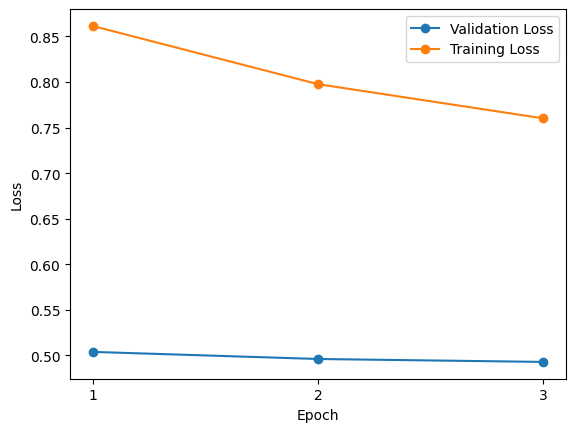

In [50]:
#Plot the graph  of the losses
import matplotlib.pyplot as plt
x=[1,2,3]
y1=df_pivot["Validation Loss"]
y2=df_pivot["Training Loss"]

plt.plot(x,y1,marker='o',label='Validation Loss')
plt.plot(x,y2, marker='o',label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)

plt.legend()

plt.show()

In [ ]:
#Find the Area between the loss curves
x = np.arange(1, k+1)

#validation_loss and Training_loss are numpy arrays. x is ephocs i think
area = np.trapezoid(abs(validation_loss - training_loss), x)


In [ ]:
#add the area column to the dataframe

In [ ]:
#give this parameters manually to the assuming dsg to the Blockchain Smart contract. see the relevance score generated
#for this
#think with exhastive proof as well for alignement.


In [21]:
#normalized training loss
import pandas as pd

# Step 1: Create the DataFrame from the given data
data = {
    'Epoch': [1, 2, 3],
    'Training Loss': [1.324800, 1.213300, 1.158600],
    'Validation Loss': [0.545930, 0.539574, 0.523401],
    'Accuracy': [0.646774, 0.648387, 0.660215]
}

df = pd.DataFrame(data)

# Step 2: Apply Min-Max Normalization to Training Loss and Validation Loss
# Min-Max normalization formula: (x - min) / (max - min)

# Normalize Training Loss
train_min = df['Training Loss'].min()
train_max = df['Training Loss'].max()
df['Normalized Training Loss'] = (df['Training Loss'] - train_min) / (train_max - train_min)

# Normalize Validation Loss
val_min = df['Validation Loss'].min()
val_max = df['Validation Loss'].max()
df['Normalized Validation Loss'] = (df['Validation Loss'] - val_min) / (val_max - val_min)

# Step 3: Save the DataFrame to a CSV file
df.to_csv('normalized_training_results.csv', index=False)

# Print the DataFrame to check the result
print(df)


   Epoch  Training Loss  Validation Loss  Accuracy  Normalized Training Loss  \
0      1         1.3248         0.545930  0.646774                  1.000000   
1      2         1.2133         0.539574  0.648387                  0.329122   
2      3         1.1586         0.523401  0.660215                  0.000000   

   Normalized Validation Loss  
0                    1.000000  
1                    0.717875  
2                    0.000000  


In [22]:
import pandas as pd

# Step 1: Create the DataFrame from the given data
data = {
    'Epoch': [1, 2, 3],
    'Training Loss': [1.324800, 1.213300, 1.158600],
    'Validation Loss': [0.545930, 0.539574, 0.523401],
    'Accuracy': [0.646774, 0.648387, 0.660215]
}

df = pd.DataFrame(data)

# Step 2: Apply Min-Max Normalization to Training Loss and Validation Loss
# Normalize Training Loss
train_min = df['Training Loss'].min()
train_max = df['Training Loss'].max()
df['Normalized Training Loss'] = (df['Training Loss'] - train_min) / (train_max - train_min)

# Normalize Validation Loss
val_min = df['Validation Loss'].min()
val_max = df['Validation Loss'].max()
df['Normalized Validation Loss'] = (df['Validation Loss'] - val_min) / (val_max - val_min)

# Step 3: Check if the proportion between normalized training loss and validation loss is maintained
# The ratio between normalized training loss and validation loss should be similar to the original ratio.

# Optionally print to check if the proportion is maintained:
df['Proportion (Training/Validation)'] = df['Normalized Training Loss'] / df['Normalized Validation Loss']

# Step 4: Save the DataFrame to a CSV file
df.to_csv('normalized_training_results_with_proportion.csv', index=False)

# Print the DataFrame to check the result
print(df)


   Epoch  Training Loss  Validation Loss  Accuracy  Normalized Training Loss  \
0      1         1.3248         0.545930  0.646774                  1.000000   
1      2         1.2133         0.539574  0.648387                  0.329122   
2      3         1.1586         0.523401  0.660215                  0.000000   

   Normalized Validation Loss  Proportion (Training/Validation)  
0                    1.000000                          1.000000  
1                    0.717875                          0.458467  
2                    0.000000                               NaN  


In [23]:
# Z normalization

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Data
data = {
    "Epoch": [1, 2, 3],
    "Training Loss": [1.324800, 1.213300, 1.158600],
    "Validation Loss": [0.545930, 0.539574, 0.523401],
    "Accuracy": [0.646774, 0.648387, 0.660215]
}

# Create DataFrame
df = pd.DataFrame(data)

# Initialize StandardScaler
scaler = StandardScaler()

# Z-normalize the Training Loss and Validation Loss
df[['Training Loss', 'Validation Loss']] = scaler.fit_transform(df[['Training Loss', 'Validation Loss']])

# Display the DataFrame
print(df)


   Epoch  Training Loss  Validation Loss  Accuracy
0      1       1.338460         1.015216  0.646774
1      2      -0.273765         0.345036  0.648387
2      3      -1.064695        -1.360252  0.660215


In [153]:
# -------------------------
# 4. Define model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
model = model.to(device)

# -------------------------
# 5. Define metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}

# -------------------------
# 6. Training arguments
# -------------------------
training_args = TrainingArguments(
    output_dir="./resnet18_binary",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=1e-4,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

# -------------------------
# 7. Define Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=NR_1_DS["train"],
    eval_dataset=NR_1_DS["validation"],
    compute_metrics=compute_metrics,
)

# -------------------------
# 8. Train
# -------------------------
trainer.train()

# -------------------------
# 9. Plot metrics per epoch
# -------------------------
log_history = trainer.state.log_history

Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


TypeError: Caught TypeError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/parallel/parallel_apply.py", line 96, in _worker
    output = module(*input, **kwargs)
  File "/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/prudhvi/anaconda3/envs/NNv2/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
TypeError: forward() got an unexpected keyword argument 'labels'


In [127]:
NR_1_DS["train"] = NR_1_DS["train"].remove_columns(["image"])
NR_1_DS["validation"] = NR_1_DS["validation"].remove_columns(["image"])

In [134]:
example

Dataset({
    features: ['label'],
    num_rows: 1860
})

In [121]:
print(type(example['pixel_values']))

<class 'torch.Tensor'>


In [122]:
import torch
from torch import nn
from torchvision import transforms, models
from transformers import TrainingArguments, Trainer
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [124]:
# -------------------------
# 4. Define model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
model = model.to(device)

# -------------------------
# 5. Define metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}

# -------------------------
# 6. Training arguments
# -------------------------
training_args = TrainingArguments(
    output_dir="./resnet18_binary",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=1e-4,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

# -------------------------
# 7. Define Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=NR_1_DS["train"],
    eval_dataset=NR_1_DS["validation"],
    compute_metrics=compute_metrics,
)

# -------------------------
# 8. Train
# -------------------------
trainer.train()

# -------------------------
# 9. Plot metrics per epoch
# -------------------------
log_history = trainer.state.log_history

Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


RuntimeError: Could not infer dtype of JpegImageFile

## Resnet 18 Model version 2

In [86]:
import torch
from torch import nn
from torchvision import transforms, models
from transformers import TrainingArguments, Trainer
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------
# 1. Load dataset with automatic 80/20 split
# -------------------------
dataset = load_dataset(
    "imagefolder",
    data_dir="/home/prudhvi/NNPractice/Datasetv2/NR_1_DS/",
    split={"train": "train[:80%]", "validation": "train[80%:]"}
)

print(dataset)

Resolving data files:   0%|          | 0/2325 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1860
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 465
    })
})


In [94]:
# -------------------------
# 2. Define transforms
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



In [95]:
# -------------------------
# 3. Apply transforms to datasets
# -------------------------
from PIL import Image

def transform_train2(example):
    # If batch (list of images)
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            train_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        # Single example
        example["pixel_values"] = train_transform(example["image"].convert("RGB"))
    return example

def transform_val2(example):
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            val_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        example["pixel_values"] = val_transform(example["image"].convert("RGB"))
    return example


In [96]:
dataset["train"] = dataset["train"].with_transform(transform_train2)
print(dataset["train"])
dataset["validation"] = dataset["validation"].with_transform(transform_val2)
print(type(dataset["train"]))

Dataset({
    features: ['image', 'label'],
    num_rows: 1860
})
<class 'datasets.arrow_dataset.Dataset'>


In [92]:
dataset["train"]

Dataset({
    features: ['image', 'label'],
    num_rows: 1860
})

In [81]:
dataset = dataset.rename_column("label", "labels")

In [82]:
dataset["train"] = dataset["train"].remove_columns(["image"])
dataset["validation"] = dataset["validation"].remove_columns(["image"])

In [85]:
dataset["train"][0]

KeyError: 'image'

In [ ]:
# -------------------------
# 4. Define model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
model = model.to(device)

# -------------------------
# 5. Define metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}

# -------------------------
# 6. Training arguments
# -------------------------
training_args = TrainingArguments(
    output_dir="./resnet18_binary",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=1e-4,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

# -------------------------
# 7. Define Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
)

# -------------------------
# 8. Train
# -------------------------
trainer.train()

# -------------------------
# 9. Plot metrics per epoch
# -------------------------
log_history = trainer.state.log_history

In [37]:
def transform_train(example):
    # Check if this is a batch or single example
    if isinstance(example["image"], list):
        # batch of images
        example["pixel_values"] = [train_transform(img.convert("RGB")) for img in example["image"]]
    else:
        # single image
        example["pixel_values"] = train_transform(example["image"].convert("RGB"))
    return example

def transform_val(example):
    if isinstance(example["image"], list):
        example["pixel_values"] = [val_transform(img.convert("RGB")) for img in example["image"]]
    else:
        example["pixel_values"] = val_transform(example["image"].convert("RGB"))
    return example
dataset["train"] = dataset["train"].with_transform(transform_train)
dataset["validation"] = dataset["validation"].with_transform(transform_val)

In [39]:
dataset["train"][].column_names

['image', 'label']

In [56]:
from PIL import Image

def transform_train1(example):
    # If batch (list of images)
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            train_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        # Single example
        example["pixel_values"] = train_transform(example["image"].convert("RGB"))
    return example

def transform_val1(example):
    if isinstance(example["image"], list):
        example["pixel_values"] = [
            val_transform(img.convert("RGB")) for img in example["image"]
        ]
    else:
        example["pixel_values"] = val_transform(example["image"].convert("RGB"))
    return example


In [57]:
dataset["train"] = dataset["train"].with_transform(transform_train1)
dataset["validation"] = dataset["validation"].with_transform(transform_val1)


In [63]:
dataset["train"][0].keys()

dict_keys(['image', 'labels', 'pixel_values'])

In [66]:
print(type(dataset["train"][0]['pixel_values']))

<class 'torch.Tensor'>


In [62]:
dataset = dataset.rename_column("label", "labels")

In [65]:
# -------------------------
# 4. Define model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
model = model.to(device)

# -------------------------
# 5. Define metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    return {"accuracy": acc}

# -------------------------
# 6. Training arguments
# -------------------------
training_args = TrainingArguments(
    output_dir="./resnet18_binary",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=1e-4,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

# -------------------------
# 7. Define Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
)

# -------------------------
# 8. Train
# -------------------------
trainer.train()

# -------------------------
# 9. Plot metrics per epoch
# -------------------------
log_history = trainer.state.log_history

Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


RuntimeError: Could not infer dtype of JpegImageFile

In [ ]:
epochs = []
train_losses = []
val_losses = []
val_accuracies = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_losses.append(log["loss"])
        epochs.append(log["epoch"])
    if "eval_loss" in log and "epoch" in log:
        val_losses.append(log["eval_loss"])
    if "eval_accuracy" in log and "epoch" in log:
        val_accuracies.append(log["eval_accuracy"])

plt.figure(figsize=(8,6))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")
plt.plot(epochs, val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training / Validation Metrics per Epoch")
plt.legend()
plt.grid(True)
plt.show()

Resolving data files:   0%|          | 0/2325 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1860
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 465
    })
})


Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


KeyError: 'image'

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already ran `trainer.train()`

# Extract log history
log_history = trainer.state.log_history

# Prepare lists
epochs = []
train_losses = []
val_losses = []
val_accuracies = []

for log in log_history:
    # Only consider logs that contain 'loss' or 'eval_loss' or 'eval_accuracy'
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_losses.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        val_losses.append(log['eval_loss'])
    if 'eval_accuracy' in log and 'epoch' in log:
        val_accuracies.append(log['eval_accuracy'])

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss, Validation Loss, and Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()
